# First Title
## Second Title
- item 1
- item 2
- item 3
**abcde**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("練習檔.csv")
df.head()

,Date,InvoNo,CustomerKey,Amount
0,2018/04/02,AP1803827,A1067,836.0
1,2018/04/03,AP1808235,A1129,836.0
2,2018/04/04,AP1807305,A1133,836.0
3,2018/04/05,AP1806145,A0464,836.0
4,2018/04/05,AP1803092,A0383,836.0


In [5]:
# 假設你的原始 DataFrame 叫做 df，欄位名稱分別為：
# 'CustomerKey', 'Date', 'InvoNo', 'Amount'

# 1. 確保Date欄位是 datetime 格式
df['Date'] = pd.to_datetime(df['Date'])

# 2. 設定「與客戶交易Date最大值的差額」所要比較的基準Date (Max Date)
# 這裡抓取全部資料中的最大Date作為基準點（也可以根據需求自行帶入特定Date，例如 pd.to_datetime('2026-12-31')）
max_date = df['Date'].max()

# 3. 進行 groupby 計算
result_df = df.groupby('CustomerKey').agg(
    F=('InvoNo', 'count'),  # InvoNo計數
    M=('Amount', 'sum'),  # Amount加總
    Last_Date=('Date', 'max'),  # 每個客戶的最後交易日
).reset_index()

# 4. 計算 R：基準Date最大值 與 該客戶最大Date的差額（以天數表示）
result_df['R'] = (max_date - result_df['Last_Date']).dt.days

# 5. 重新命名欄位並調整順序，符合你的要求：Customer, F, M, R
result_df = result_df.rename(columns={'CustomerKey': 'Customer'})
result_df = result_df[['Customer', 'F', 'M', 'R']]

# 查看結果
print(result_df)

    Customer   F            M   R
0      A0350  25  51238.11440   9
1      A0351   6  17890.31200  16
2      A0352  14  46424.03852  14
3      A0353  14  27607.68636  24
4      A0354   6   9973.92064  31
..       ...  ..          ...  ..
727    A1413  23  52738.79456  10
728    A1415  20  53019.49664  17
729    A1416  24  49938.38378   4
730    A1419  22  64257.84520  50
731    A1420  14  25054.18342  85

[732 rows x 4 columns]


In [ ]:
result_df.to_csv("RFM_DATA.csv",index=False)

In [6]:
import pandas as pd

rfm_df = pd.read_csv('RFM_DATA.csv')
display(rfm_df.head())

,Customer,F,M,R
0,A0350,25,51238.11440,9
1,A0351,6,17890.31200,16
2,A0352,14,46424.03852,14
3,A0353,14,27607.68636,24
4,A0354,6,9973.92064,31


In [7]:
from sklearn.preprocessing import MinMaxScaler

# 複製一份 DataFrame 以免更動到原始資料
nrfm = rfm_df.copy()

# 初始化 MinMaxScaler
scaler = MinMaxScaler()

# 對 F, M, R 欄位進行正規化
nrfm[['F', 'M', 'R']] = scaler.fit_transform(nrfm[['F', 'M', 'R']])

# 顯示正規化後的結果
display(nrfm.head())

,Customer,F,M,R
0,A0350,0.631579,0.376563,0.024523
1,A0351,0.131579,0.127866,0.043597
2,A0352,0.342105,0.340662,0.038147
3,A0353,0.342105,0.200335,0.065395
4,A0354,0.131579,0.068827,0.084469


C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak o

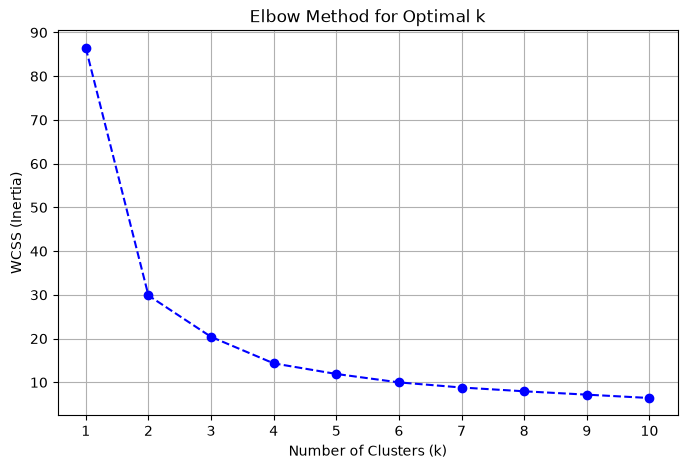

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 提取用於分群的特徵欄位 (F, M, R)
features = nrfm[['F', 'M', 'R']]

wcss = []
k_range = range(1, 11)

# 計算各個 k 值的 WCSS
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features)
    wcss.append(kmeans.inertia_)

# 繪製 Elbow Chart
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [9]:
from sklearn.cluster import KMeans

# 設定群數為 4
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# 使用正規化後的 F, M, R 進行訓練與預測
cluster_labels = kmeans.fit_predict(nrfm[['F', 'M', 'R']])

# 將分群結果加入至 DataFrame 中
nrfm['Cluster'] = cluster_labels
rfm_df['Cluster'] = cluster_labels

# 顯示前 5 筆分群結果
print("--- 正規化資料 (nrfm) 加上分群結果 ---")
display(nrfm.head())

print("\n--- 原始資料 (rfm_df) 加上分群結果 ---")
display(rfm_df.head())

--- 正規化資料 (nrfm) 加上分群結果 ---


C:\Users\student\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


,Customer,F,M,R,Cluster
0,A0350,0.631579,0.376563,0.024523,1
1,A0351,0.131579,0.127866,0.043597,2
2,A0352,0.342105,0.340662,0.038147,1
3,A0353,0.342105,0.200335,0.065395,1
4,A0354,0.131579,0.068827,0.084469,2



--- 原始資料 (rfm_df) 加上分群結果 ---


,Customer,F,M,R,Cluster
0,A0350,25,51238.11440,9,1
1,A0351,6,17890.31200,16,2
2,A0352,14,46424.03852,14,1
3,A0353,14,27607.68636,24,1
4,A0354,6,9973.92064,31,2


In [11]:
kmeans.labels_

array([1, 2, 1, 1, 2, 2, 2, 1, 2, 2, 0, 2, 1, 2, 1, 2, 2, 3, 0, 3, 0, 1,
       1, 2, 1, 1, 2, 2, 2, 2, 2, 1, 0, 1, 2, 2, 2, 3, 2, 2, 1, 3, 1, 1,
       0, 2, 1, 2, 2, 1, 2, 0, 2, 1, 3, 1, 1, 0, 2, 0, 2, 1, 1, 2, 2, 1,
       3, 2, 2, 1, 0, 2, 2, 2, 1, 1, 1, 0, 3, 1, 3, 2, 2, 1, 1, 1, 1, 2,
       2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 2,
       2, 2, 1, 3, 1, 1, 2, 1, 1, 2, 1, 2, 2, 1, 3, 1, 3, 1, 2, 2, 2, 1,
       2, 2, 0, 1, 3, 0, 1, 2, 2, 1, 1, 0, 2, 0, 2, 2, 2, 2, 2, 3, 2, 1,
       1, 2, 2, 3, 1, 2, 2, 2, 1, 2, 2, 1, 2, 2, 0, 1, 2, 3, 0, 3, 2, 1,
       3, 2, 0, 2, 2, 0, 1, 3, 3, 3, 1, 2, 2, 2, 2, 3, 2, 1, 0, 2, 0, 0,
       1, 1, 1, 3, 2, 2, 1, 0, 2, 1, 2, 0, 3, 2, 1, 1, 2, 2, 1, 1, 2, 1,
       3, 2, 1, 1, 2, 1, 2, 1, 1, 2, 2, 1, 3, 2, 2, 2, 2, 1, 2, 3, 2, 0,
       1, 2, 2, 2, 0, 0, 3, 2, 0, 0, 1, 2, 0, 2, 3, 3, 1, 1, 2, 1, 1, 2,
       3, 2, 2, 2, 1, 3, 1, 3, 3, 2, 2, 2, 0, 1, 2, 1, 1, 2, 2, 2, 3, 2,
       2, 1, 2, 2, 2, 2, 1, 1, 1, 2, 1, 1, 3, 1, 3,

In [18]:
# 載入 Silhouette 套件，為驗證分組成效，需要執行 Silhouette 分析
from sklearn.metrics import silhouette_samples
silhouette=silhouette_samples(nrfm[["R","F","M"]], nrfm.Cluster)

Text(0.5, 0, 'Item No')

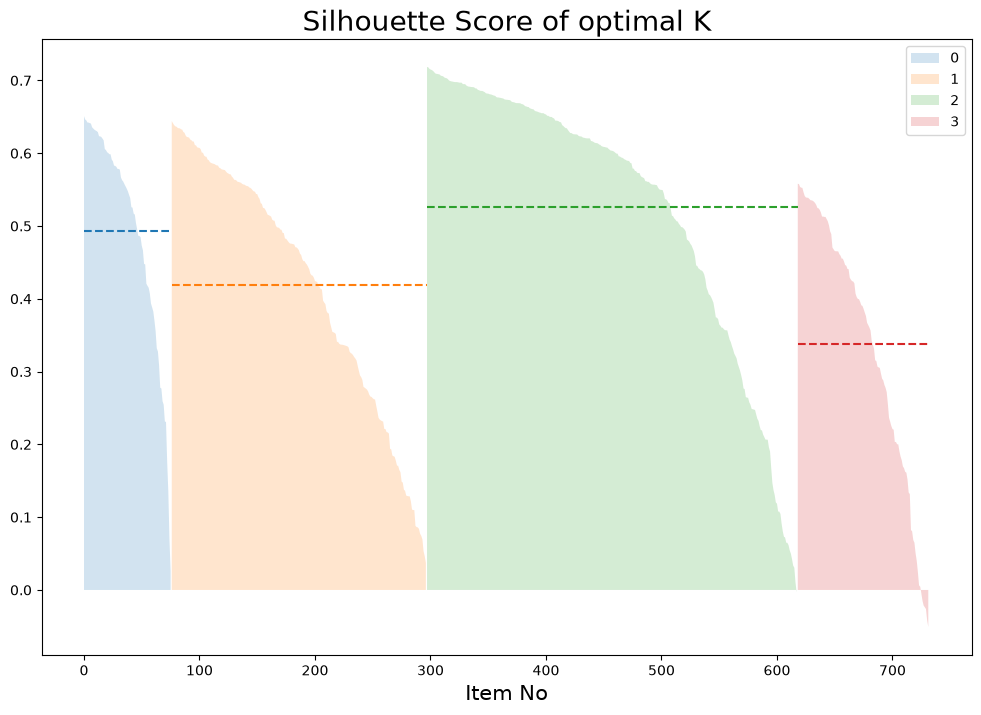

In [21]:
# 01 設定畫布尺寸
# 02 初始類別軸起始點
# 03 繪製 Silhouette 圖

# k=4 #承繼前段 k-means 分組數
plt.figure(figsize=[12,8]) #01
x0=0 #02

#03
for i in range(k):
   
    group_slh=silhouette[nrfm.Cluster==i] # 取出 i 組 silhouette 分數表
    x=range(x0,x0+len(group_slh)) # 以 i 組序列範圍為類別軸 (x)

    y=-np.sort(-group_slh) # 將 i 組 silhouette 分數表依遞減排序，為數值軸 (y)
    yavg=np.average(group_slh) # 計算 i 組 silhouette 分數平均值，為數值軸參考線

    plt.fill_between(x,y,alpha=0.2,label=i) # 繪圖區填滿
 
    plt.plot([x0,x0+len(group_slh)],[yavg,yavg],'--') # 標註平均線
   
    plt.legend() # 繪製圖例
       
    x0=x0+len(group_slh) # 設定次組類別軸起始點

plt.title('Silhouette Score of optimal K',fontsize=20)
plt.xlabel('Item No',fontsize=15)

In [22]:
# 計算並顯示各群的平均值（以原始數值檢視各群特徵）
cluster_summary = rfm_df.groupby('Cluster').agg(
    Customer_Count=('Customer', 'count'),
    F_Mean=('F', 'mean'),
    M_Mean=('M', 'mean'),
    R_Mean=('R', 'mean')
).reset_index()

print("\n--- 各分群的 RFM 特徵平均值 ---")
display(cluster_summary)


--- 各分群的 RFM 特徵平均值 ---


,Cluster,Customer_Count,F_Mean,M_Mean,R_Mean
0,0,76,3.657895,8569.692582,182.723684
1,1,221,19.316742,45267.863586,17.710407
2,2,321,5.694704,14127.145096,44.479751
3,3,114,26.368421,76632.327280,15.315789


In [23]:
import pandas as pd

# 0. 重新讀取原始交易資料並定義為 df
df = pd.read_csv('練習檔.csv')

# 1. 建立客戶與分群的對照表 (rfm_df 中的 Customer 對應到 df 中的 CustomerKey)
cluster_mapping = rfm_df[['Customer', 'Cluster']].rename(columns={'Customer': 'CustomerKey'})

# 2. 將分群標籤 Cluster 合併回原始資料 df 中
df = df.merge(cluster_mapping, on='CustomerKey', how='left')

# 3. 顯示合併後的前 10 筆原始資料，確認 Cluster 欄位已成功加上
display(df.head(10))

,Date,InvoNo,CustomerKey,Amount,Cluster
0,2018/04/02,AP1803827,A1067,836.0,1
1,2018/04/03,AP1808235,A1129,836.0,1
2,2018/04/04,AP1807305,A1133,836.0,1
3,2018/04/05,AP1806145,A0464,836.0,3
4,2018/04/05,AP1803092,A0383,836.0,2
5,2018/04/05,AP1808187,A0949,836.0,1
6,2018/04/06,AP1804369,A0525,836.0,2
7,2018/04/06,AP1800269,A0961,836.0,1
8,2018/04/06,AP1801477,A1212,836.0,3
9,2018/04/10,AP1808060,A1165,836.0,2


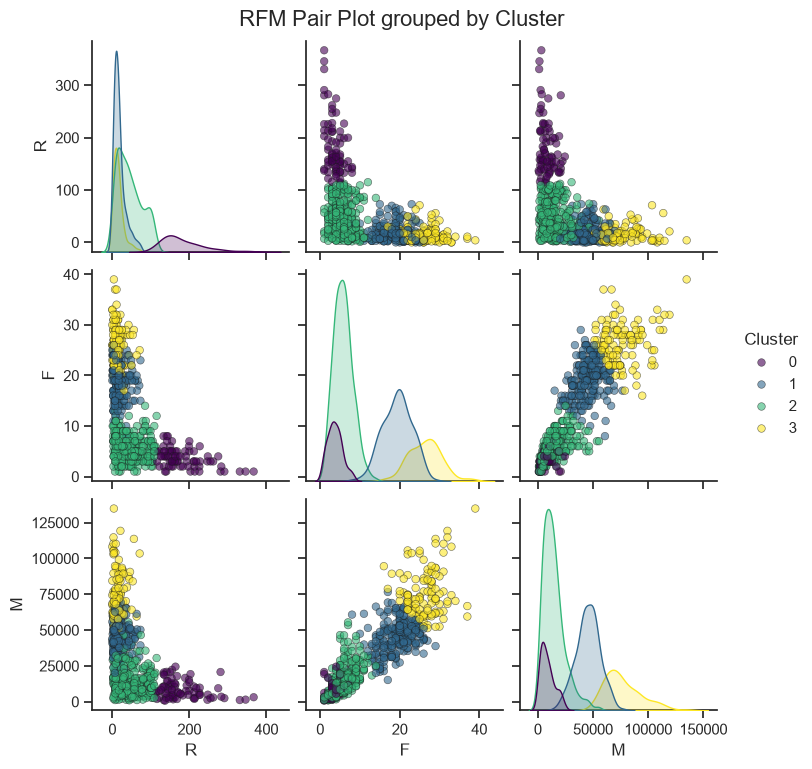

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# 由於我們需要原始的 R, F, M 數值，我們先將交易明細 df 與 rfm_df 的 R, F, M 欄位及 Cluster 合併
# 或者是直接使用已經計算好每位客戶 RFM 特徵與 Cluster 的 rfm_df 來繪製 Pair Plot 更加直觀與精確。
# 這裡我們使用 rfm_df 進行繪圖，並以 'Cluster' 分組作色：

# 設定繪圖風格與字型
sns.set_theme(style="ticks")

# 繪製 Pair Plot
g = sns.pairplot(
    rfm_df[['R', 'F', 'M', 'Cluster']],
    hue='Cluster',
    palette='viridis',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k'}
)

g.fig.suptitle("RFM Pair Plot grouped by Cluster", y=1.02, fontsize=16)
plt.show()

In [25]:
# 定義 Cluster 與 Group 的對應關係
group_mapping = {
    0: 'Missing',
    1: 'High',
    2: 'Low',
    3: 'Medium'
}

# 新增 Group 欄位並進行對應
df['Group'] = df['Cluster'].map(group_mapping)

# 顯示前 10 筆資料，確認 Group 欄位已正確對應
display(df.head(10))

,Date,InvoNo,CustomerKey,Amount,Cluster,Group
0,2018/04/02,AP1803827,A1067,836.0,1,High
1,2018/04/03,AP1808235,A1129,836.0,1,High
2,2018/04/04,AP1807305,A1133,836.0,1,High
3,2018/04/05,AP1806145,A0464,836.0,3,Medium
4,2018/04/05,AP1803092,A0383,836.0,2,Low
5,2018/04/05,AP1808187,A0949,836.0,1,High
6,2018/04/06,AP1804369,A0525,836.0,2,Low
7,2018/04/06,AP1800269,A0961,836.0,1,High
8,2018/04/06,AP1801477,A1212,836.0,3,Medium
9,2018/04/10,AP1808060,A1165,836.0,2,Low


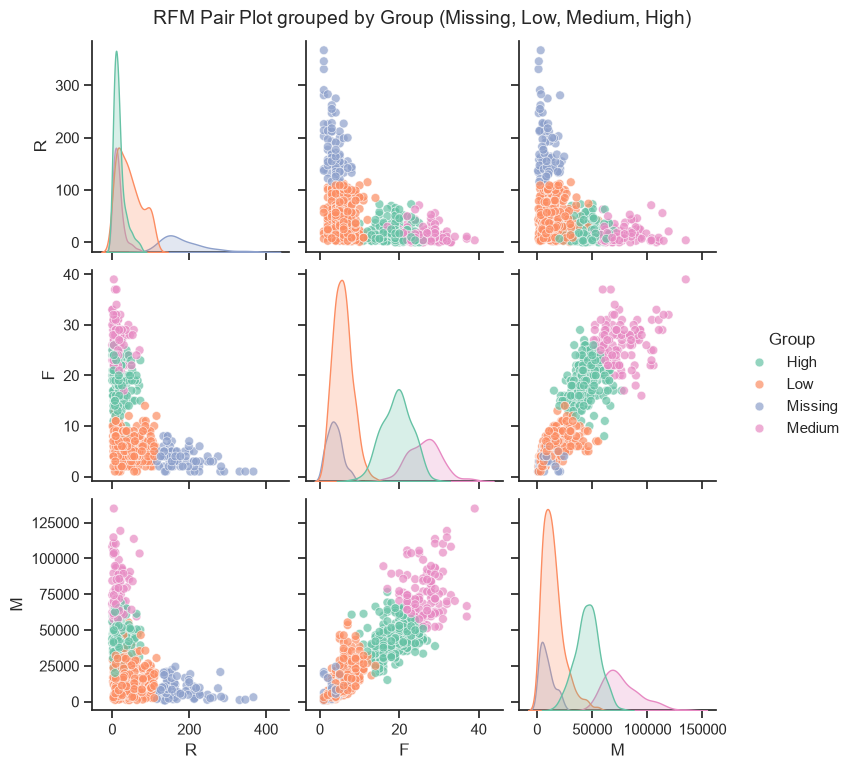

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 為了使用 df 並繪製顧客層級的 R, F, M，我們直接將 rfm_df 中的 R, F, M 與剛才新增的 Group 合併
# 這樣能確保每一位顧客的 RFM 數值能與其對應的文字 Group 正確連結進行圖表繪製
rfm_with_group = rfm_df.copy()
rfm_with_group['Group'] = rfm_with_group['Cluster'].map(group_mapping)

# 2. 設定繪圖風格
sns.set_theme(style="ticks")

# 3. 繪製以 Group 標籤分組的 Pair Plot
g = sns.pairplot(
    rfm_with_group[['R', 'F', 'M', 'Group']],
    hue='Group',
    palette='Set2',
    diag_kind='kde',
    plot_kws={'alpha': 0.7, 's': 40, 'edgecolor': 'w'}
)

g.fig.suptitle("RFM Pair Plot grouped by Group (Missing, Low, Medium, High)", y=1.02, fontsize=14)
plt.show()

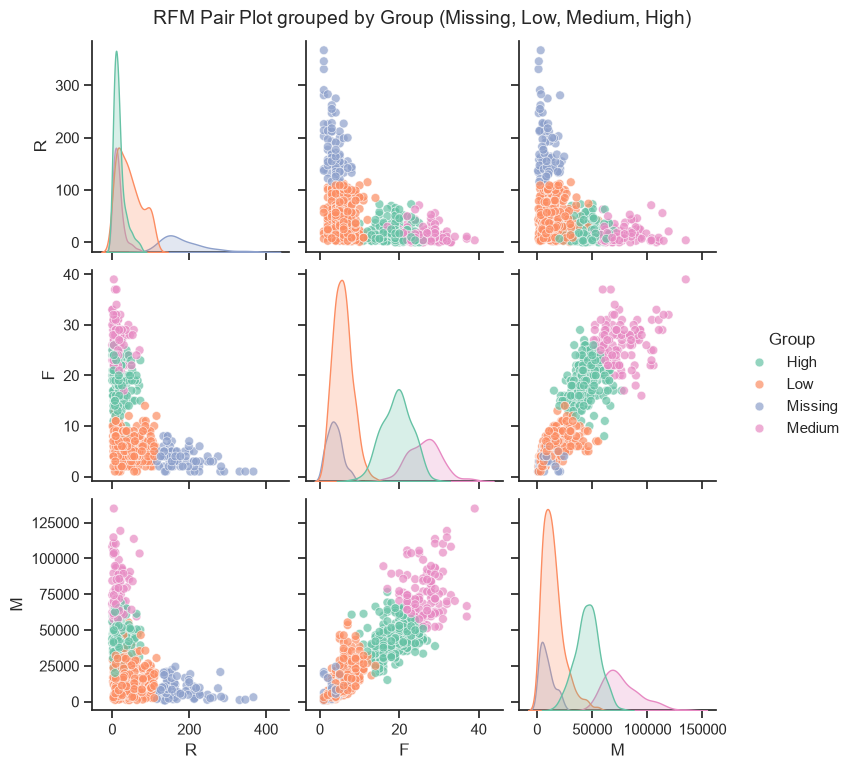

圖片已成功儲存為透明背景格式：RFM_Pairplot.png


In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# 設定風格
sns.set_theme(style="ticks")

# 繪製以 Group 標籤分組的 Pair Plot
g = sns.pairplot(
    rfm_with_group[['R', 'F', 'M', 'Group']],
    hue='Group',
    palette='Set2',
    diag_kind='kde',
    plot_kws={'alpha': 0.7, 's': 40, 'edgecolor': 'w'}
)

g.fig.suptitle("RFM Pair Plot grouped by Group (Missing, Low, Medium, High)", y=1.02, fontsize=14)

# 儲存為透明圖格式
plt.savefig('RFM_Pairplot.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()
print("圖片已成功儲存為透明背景格式：RFM_Pairplot.png")

In [28]:
# 將 df 匯出為 RFM_result.csv 并提供下載
df.to_csv('RFM_result.csv', index=False, encoding='utf-8-sig')

from google.colab import files
files.download('RFM_result.csv')
print("已成功將資料匯出並觸發下載：RFM_result.csv")

ModuleNotFoundError: No module named 'google.colab'